# Обучаю модель, использую метод логтя

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [15]:
df = pd.read_csv(r"gene_expression.csv")

In [16]:
df.head()

,Gene One,Gene Two,Cancer Present
0,4.3,3.9,1
1,2.5,6.3,0
2,5.7,3.9,1
3,6.1,6.2,0
4,7.4,3.4,1


In [17]:
# два гена и наличие рака 

<Axes: xlabel='Gene One', ylabel='Gene Two'>

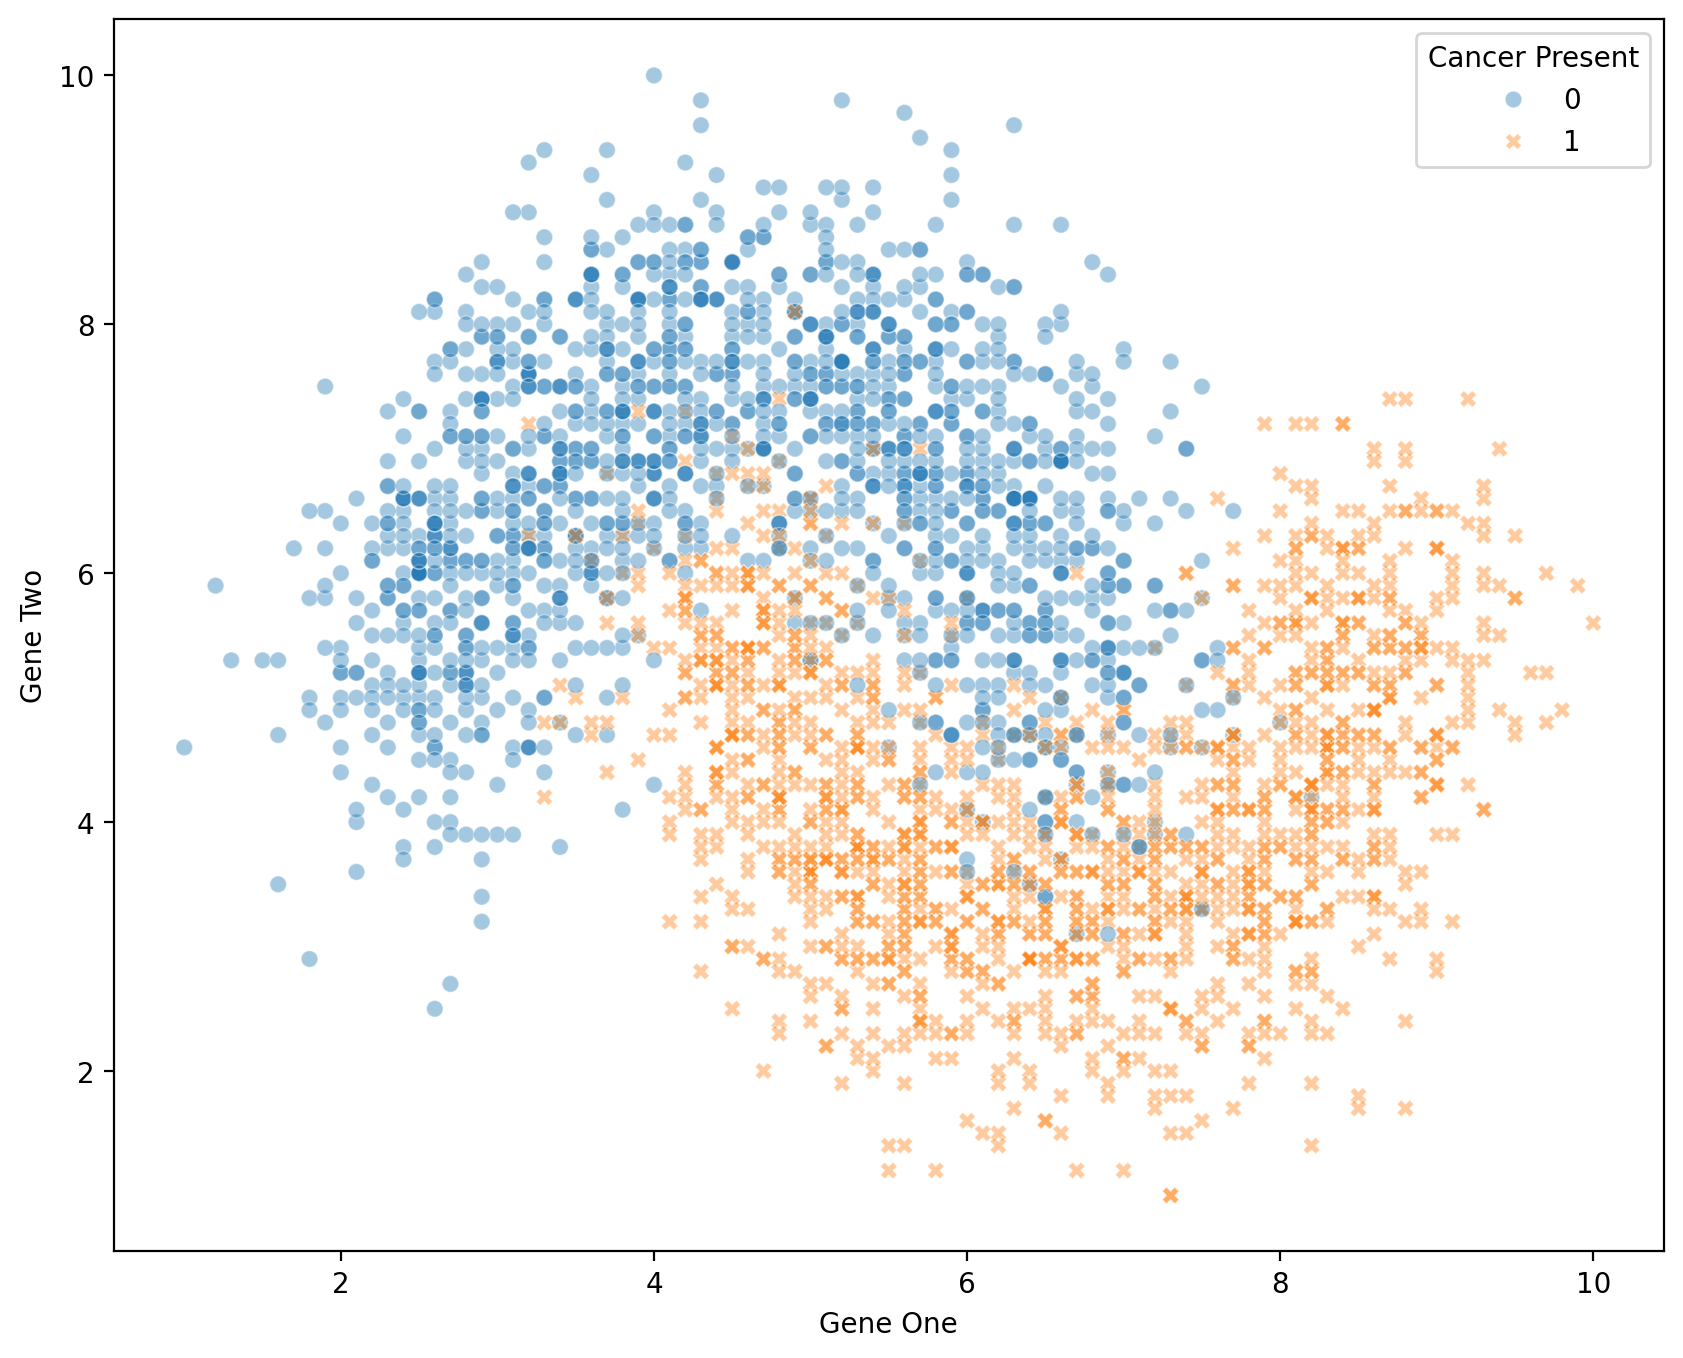

In [18]:
fig, ax = plt.subplots(figsize=(10, 8), dpi=200)
sns.scatterplot(data=df, x='Gene One', y='Gene Two', hue='Cancer Present', alpha=0.4, ax=ax, style='Cancer Present')


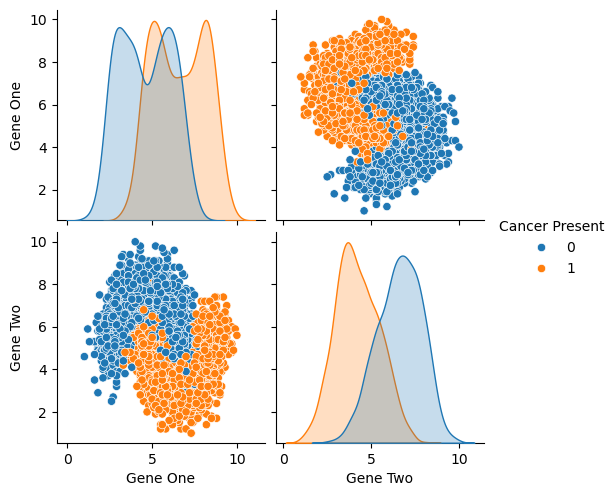

In [19]:
sns.pairplot(data=df, hue='Cancer Present')

In [20]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier # потому что задача классификации

In [21]:
X = df.drop('Cancer Present', axis=1)
y = df['Cancer Present']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.3, random_state=101)

scaler = StandardScaler()
X_scaler_train = scaler.fit_transform(X_train)
X_scaler_test  = scaler.transform(X_test)

In [22]:
# параметр weigth  когда указываем какие признаки более важные чем остальные
# по умолчанию uniform

# n_neighbors  колво соседей

In [23]:
knn_1 = KNeighborsClassifier(n_neighbors=1)
knn_1.fit(X_scaler_train, y_train)

,n_neighbors,1
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [24]:
y_pred = knn_1.predict(X_scaler_test)


In [25]:
from sklearn.metrics import confusion_matrix, classification_report

In [26]:
confusion_matrix(y_test, y_pred)

array([[382,  41],
       [ 34, 443]])

In [27]:
len(y_test)

900

In [28]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.92      0.90      0.91       423
           1       0.92      0.93      0.92       477

    accuracy                           0.92       900
   macro avg       0.92      0.92      0.92       900
weighted avg       0.92      0.92      0.92       900



In [29]:
df['Cancer Present'].value_counts()

Cancer Present
1    1500
0    1500
Name: count, dtype: int64

## 2

In [30]:
from sklearn.metrics import accuracy_score

In [31]:
test_error = []

for k in range(1, 31):
    knn_model_2 = KNeighborsClassifier(n_neighbors=k)
    knn_model_2.fit(X_scaler_train, y_train)

    y_pred = knn_model_2.predict(X_scaler_test)
    error = 1 - accuracy_score(y_test, y_pred)
    test_error.append(error)  

In [32]:
test_error

[0.08333333333333337,
 0.0922222222222222,
 0.07111111111111112,
 0.06555555555555559,
 0.06444444444444442,
 0.05888888888888888,
 0.06555555555555559,
 0.06333333333333335,
 0.06555555555555559,
 0.06333333333333335,
 0.06888888888888889,
 0.06333333333333335,
 0.06444444444444442,
 0.06222222222222218,
 0.06777777777777783,
 0.061111111111111116,
 0.06000000000000005,
 0.061111111111111116,
 0.06333333333333335,
 0.06222222222222218,
 0.06222222222222218,
 0.06444444444444442,
 0.061111111111111116,
 0.06000000000000005,
 0.06222222222222218,
 0.06555555555555559,
 0.06222222222222218,
 0.061111111111111116,
 0.06222222222222218,
 0.06222222222222218]

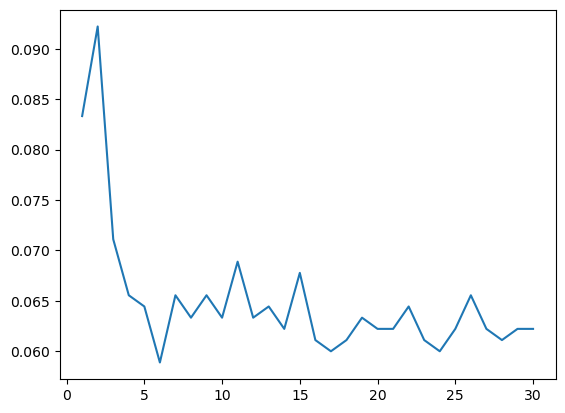

In [33]:
plt.plot(np.arange(1, 31), test_error)

In [34]:
scaler = StandardScaler()
knn    = KNeighborsClassifier()
knn.get_params()

{'algorithm': 'auto',
 'leaf_size': 30,
 'metric': 'minkowski',
 'metric_params': None,
 'n_jobs': None,
 'n_neighbors': 5,
 'p': 2,
 'weights': 'uniform'}

In [35]:

operations = [('scaler',scaler),('knn',knn)]

In [36]:
from sklearn.pipeline import Pipeline

In [37]:
pipe = Pipeline(operations)

In [38]:


from sklearn.model_selection import GridSearchCV

In [39]:
k_values = list(range(1,20))

In [40]:

param_grid = {'knn__n_neighbors': k_values}

In [41]:
full_cv_classifier = GridSearchCV(pipe,param_grid,cv=5,scoring='accuracy')

In [42]:
full_cv_classifier.fit(X_train,y_train)

,estimator,Pipeline(step...lassifier())])
,param_grid,"{'knn__n_neighbors': [1, 2, ...]}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,copy,True


In [43]:
full_cv_classifier.best_estimator_.get_params()

{'memory': None,
 'steps': [('scaler', StandardScaler()),
  ('knn', KNeighborsClassifier(n_neighbors=19))],
 'transform_input': None,
 'verbose': False,
 'scaler': StandardScaler(),
 'knn': KNeighborsClassifier(n_neighbors=19),
 'scaler__copy': True,
 'scaler__with_mean': True,
 'scaler__with_std': True,
 'knn__algorithm': 'auto',
 'knn__leaf_size': 30,
 'knn__metric': 'minkowski',
 'knn__metric_params': None,
 'knn__n_jobs': None,
 'knn__n_neighbors': 19,
 'knn__p': 2,
 'knn__weights': 'uniform'}

In [44]:
full_cv_classifier.cv_results_.keys()

dict_keys(['mean_fit_time', 'std_fit_time', 'mean_score_time', 'std_score_time', 'param_knn__n_neighbors', 'params', 'split0_test_score', 'split1_test_score', 'split2_test_score', 'split3_test_score', 'split4_test_score', 'mean_test_score', 'std_test_score', 'rank_test_score'])

In [45]:
full_cv_classifier.cv_results_['mean_test_score']

array([0.89666667, 0.90333333, 0.91714286, 0.91761905, 0.92428571,
       0.92333333, 0.92666667, 0.92714286, 0.92666667, 0.92714286,
       0.9247619 , 0.92714286, 0.92857143, 0.92809524, 0.92571429,
       0.92952381, 0.92666667, 0.93      , 0.93047619])

## Финальная модель

Как мы увидели, метод GridSearch рекомендует значение K=14 (это соответствует методу локтя, если применить его).

In [46]:
scaler = StandardScaler()
knn14 = KNeighborsClassifier(n_neighbors=14)
operations = [('scaler',scaler),('knn14',knn14)]

In [47]:
pipe = Pipeline(operations)

In [48]:
pipe.fit(X_train,y_train)

,steps,"[('scaler', ...), ('knn14', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,n_neighbors,14
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30


In [49]:
pipe_pred = pipe.predict(X_test)

In [50]:
print(classification_report(y_test,pipe_pred))

              precision    recall  f1-score   support

           0       0.93      0.93      0.93       423
           1       0.94      0.94      0.94       477

    accuracy                           0.94       900
   macro avg       0.94      0.94      0.94       900
weighted avg       0.94      0.94      0.94       900

